In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sharedfunctions import loadKernels, computeSigma, computeMagnitudeResponse, calculateEcc, eccL2Distance, eccWassersteinDistance, IDXROBUST, IDXVULNERABLE, GRIDSIZE, SIGMAGRID, NTHRESH, CSVPATH


In [19]:
kernels = loadKernels(CSVPATH)

In [20]:
sigmas = np.array([computeSigma(h) for h in kernels])
meanSigma = np.mean(sigmas)
thresholds = [0.001, 0.005, 0.01, 0.05, 0.1]

In [21]:
print(f"\n  Total kernels: {len(sigmas)}")
print(f"  Mean sigma:    {meanSigma:.6f}")
print(f"  Min sigma:     {sigmas.min():.8f}  (Kernel {np.argmin(sigmas)})")
print(f"  Max sigma:     {sigmas.max():.6f}  (Kernel {np.argmax(sigmas)})")
print(f"\n  Vulnerability Threshold Analysis:")

for thr in thresholds:
    n = np.sum(sigmas < thr)
    print(f"    sigma < {thr:.3f}: {n:4d} / {len(sigmas)} kernels  ({100*n/len(sigmas):.1f}%)")


  Total kernels: 4096
  Mean sigma:    0.007114
  Min sigma:     0.00000000  (Kernel 806)
  Max sigma:     0.414453  (Kernel 42)

  Vulnerability Threshold Analysis:
    sigma < 0.001:  929 / 4096 kernels  (22.7%)
    sigma < 0.005: 2847 / 4096 kernels  (69.5%)
    sigma < 0.010: 3559 / 4096 kernels  (86.9%)
    sigma < 0.050: 4006 / 4096 kernels  (97.8%)
    sigma < 0.100: 4063 / 4096 kernels  (99.2%)


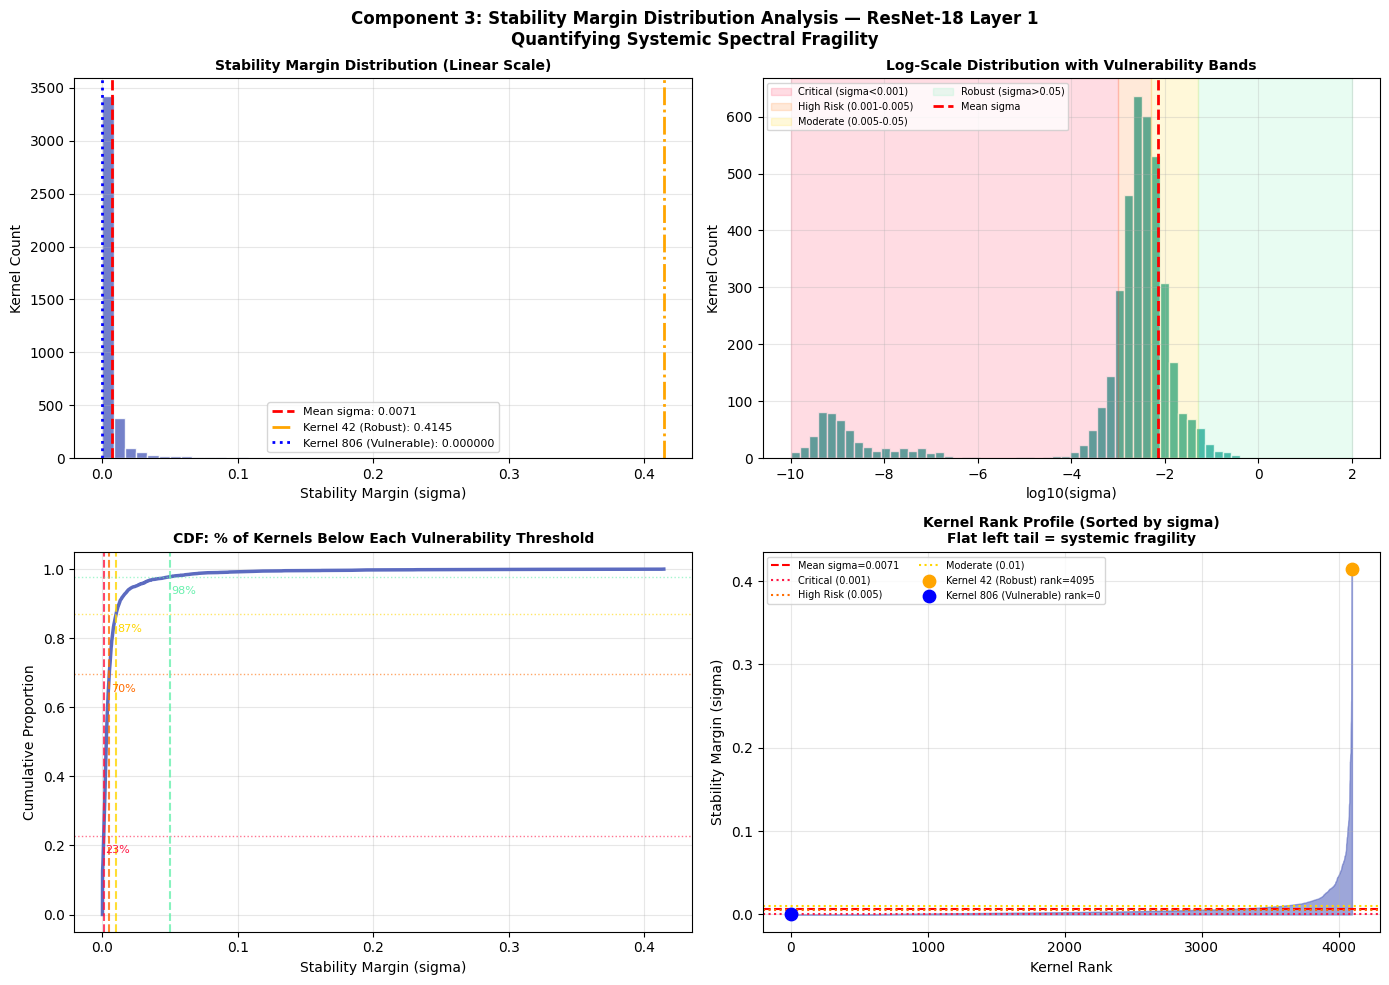

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Component 3: Stability Margin Distribution Analysis — ResNet-18 Layer 1\n"
             "Quantifying Systemic Spectral Fragility",
             fontsize=12, fontweight='bold')

ax = axes[0, 0]
ax.hist(sigmas, bins=50, color='#5c6bc0', edgecolor='white', alpha=0.85)
ax.axvline(meanSigma, color='red', linewidth=2, linestyle='--',
           label=f'Mean sigma: {meanSigma:.4f}')
ax.axvline(sigmas[IDXROBUST], color='orange', linewidth=2, linestyle='-.',
           label=f'Kernel {IDXROBUST} (Robust): {sigmas[IDXROBUST]:.4f}')
ax.axvline(sigmas[IDXVULNERABLE], color='blue', linewidth=2, linestyle=':',
           label=f'Kernel {IDXVULNERABLE} (Vulnerable): {sigmas[IDXVULNERABLE]:.6f}')
ax.set_title("Stability Margin Distribution (Linear Scale)", fontsize=10, fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)", fontsize=10)
ax.set_ylabel("Kernel Count", fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
logSigmas = np.log10(sigmas + 1e-10)
ax.hist(logSigmas, bins=50, color='#26a69a', edgecolor='white', alpha=0.85)
bandColors = ['#ff1744', '#ff6d00', '#ffd600', '#69f0ae']
bandLabels = ['Critical (sigma<0.001)', 'High Risk (0.001-0.005)',
               'Moderate (0.005-0.05)',  'Robust (sigma>0.05)']
edges = [-10, -3, np.log10(0.005), np.log10(0.05), 2]
for i in range(4):
    ax.axvspan(edges[i], edges[i+1], alpha=0.15,
               color=bandColors[i], label=bandLabels[i])
ax.axvline(np.log10(meanSigma + 1e-10), color='red', linewidth=2,
           linestyle='--', label='Mean sigma')
ax.set_title("Log-Scale Distribution with Vulnerability Bands",
             fontsize=10, fontweight='bold')
ax.set_xlabel("log10(sigma)", fontsize=10)
ax.set_ylabel("Kernel Count", fontsize=10)
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)


ax = axes[1, 0]
sortedSigmas = np.sort(sigmas)
cdf = np.arange(1, len(sortedSigmas)+1) / len(sortedSigmas)
ax.plot(sortedSigmas, cdf, color='#5c6bc0', linewidth=2.5)
for thr, col in zip([0.001, 0.005, 0.01, 0.05],
                     ['#ff1744', '#ff6d00', '#ffd600', '#69f0ae']):
    pct = np.mean(sigmas < thr)
    ax.axvline(thr, color=col, linewidth=1.5, linestyle='--', alpha=0.8)
    ax.axhline(pct, color=col, linewidth=1.0, linestyle=':', alpha=0.6)
    ax.text(thr + 0.001, pct - 0.05, f'{pct*100:.0f}%', fontsize=8, color=col)
ax.set_title("CDF: % of Kernels Below Each Vulnerability Threshold",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Stability Margin (sigma)", fontsize=10)
ax.set_ylabel("Cumulative Proportion", fontsize=10)
ax.grid(True, alpha=0.3)


ax = axes[1, 1]
ax.fill_between(np.arange(len(sortedSigmas)), sortedSigmas,
                alpha=0.6, color='#5c6bc0')
ax.axhline(meanSigma, color='red', linewidth=1.5, linestyle='--',
           label=f'Mean sigma={meanSigma:.4f}')
for thr, col, lbl in zip([0.001, 0.005, 0.01],
                           ['#ff1744', '#ff6d00', '#ffd600'],
                           ['Critical (0.001)', 'High Risk (0.005)', 'Moderate (0.01)']):
    ax.axhline(thr, color=col, linewidth=1.5, linestyle=':', label=lbl)
rank_rob = int(np.searchsorted(sortedSigmas, sigmas[IDXROBUST]))
rank_vul = int(np.searchsorted(sortedSigmas, sigmas[IDXVULNERABLE]))
ax.scatter([rank_rob], [sigmas[IDXROBUST]], color='orange', s=80, zorder=5,
           label=f'Kernel {IDXROBUST} (Robust) rank={rank_rob}')
ax.scatter([rank_vul], [sigmas[IDXVULNERABLE]], color='blue', s=80, zorder=5,
           label=f'Kernel {IDXVULNERABLE} (Vulnerable) rank={rank_vul}')
ax.set_title("Kernel Rank Profile (Sorted by sigma)\nFlat left tail = systemic fragility",
             fontsize=10, fontweight='bold')
ax.set_xlabel("Kernel Rank", fontsize=10)
ax.set_ylabel("Stability Margin (sigma)", fontsize=10)
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("SigmaDistributionAnalysis.png", dpi=150, bbox_inches='tight')

